<a href="https://colab.research.google.com/github/arnab9957/NLP/blob/main/student_performance_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load StudentsPerformance.csv into a pandas DataFrame.

In [17]:
dfv = pd.read_csv('StudentsPerformance.csv')
df = dfv.copy()

Display:
First 10 rows and last 5 rows.
Shape of the DataFrame.
Data types and non-null counts (df.info()).

In [30]:
print(df.head(10))
print(df.tail)

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   
5  female        group B          associate's degree      standard   
6  female        group B                some college      standard   
7    male        group B                some college  free/reduced   
8    male        group D                 high school  free/reduced   
9  female        group B                 high school  free/reduced   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                  

In [5]:
df.shape

(1000, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [9]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [34]:
df.columns = df.columns.str.replace(' ', '_')

print(df.columns)

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


In [32]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 1.Using NumPy, compute for each subject:
Mean, median, standard deviation, minimum, maximum.
25th, 50th, and 75th percentiles.

In [39]:
subject_scores = ['math_score', 'reading_score', 'writing_score']

for subject in subject_scores:
    print(f"\n {subject.upper()} STATISTICS ")
    print(f"Mean: {np.mean(df[subject]):.2f}")
    print(f"Median: {np.median(df[subject]):.2f}")
    print(f"Standard Deviation: {np.std(df[subject]):.2f}")
    print(f"Minimum: {np.min(df[subject])}")
    print(f"Maximum: {np.max(df[subject])}")
    print(f"25th Percentile: {np.percentile(df[subject], 25):.2f}")
    print(f"50th Percentile: {np.percentile(df[subject], 50):.2f}")
    print(f"75th Percentile: {np.percentile(df[subject], 75):.2f}")


 MATH_SCORE STATISTICS 
Mean: 66.09
Median: 66.00
Standard Deviation: 15.16
Minimum: 0
Maximum: 100
25th Percentile: 57.00
50th Percentile: 66.00
75th Percentile: 77.00

 READING_SCORE STATISTICS 
Mean: 69.17
Median: 70.00
Standard Deviation: 14.59
Minimum: 17
Maximum: 100
25th Percentile: 59.00
50th Percentile: 70.00
75th Percentile: 79.00

 WRITING_SCORE STATISTICS 
Mean: 68.05
Median: 69.00
Standard Deviation: 15.19
Minimum: 10
Maximum: 100
25th Percentile: 57.75
50th Percentile: 69.00
75th Percentile: 79.00


### Average Score Per Subject Grouped by Gender

In [41]:
avg_score_gender = df.groupby('gender')[subject_scores].mean()
display(avg_score_gender)

higher_math_gender = avg_score_gender['math_score'].idxmax()
print(f"\nGender with higher average math score: {higher_math_gender}")

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203



Gender with higher average math score: male


### Average Score Per Subject Grouped by Lunch Type

In [40]:
avg_score_lunch = df.groupby('lunch')[subject_scores].mean()
display(avg_score_lunch)

higher_reading_lunch = avg_score_lunch['reading_score'].idxmax()
print(f"\nLunch type associated with higher average reading score: {higher_reading_lunch}")

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256



Lunch type associated with higher average reading score: standard


### Average Score Per Subject Grouped by Parental Level of Education

In [45]:
avg_score_parental_education = df.groupby('parental_level_of_education')[subject_scores].mean().sort_values(by='writing_score', ascending=False)
display(avg_score_parental_education)

highest_writing_education = avg_score_parental_education['writing_score'].idxmax()
print(f"\nParental education level corresponding to the highest average writing score: {highest_writing_education}")

,math_score,reading_score,writing_score
parental_level_of_education,,,
master's degree,69.745763,75.372881,75.677966
bachelor's degree,69.389831,73.000000,73.381356
associate's degree,67.882883,70.927928,69.896396
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268
high school,62.137755,64.704082,62.448980



Parental education level corresponding to the highest average writing score: master's degree


## Visualizations

### 1. Histograms for Math, Reading, and Writing Scores

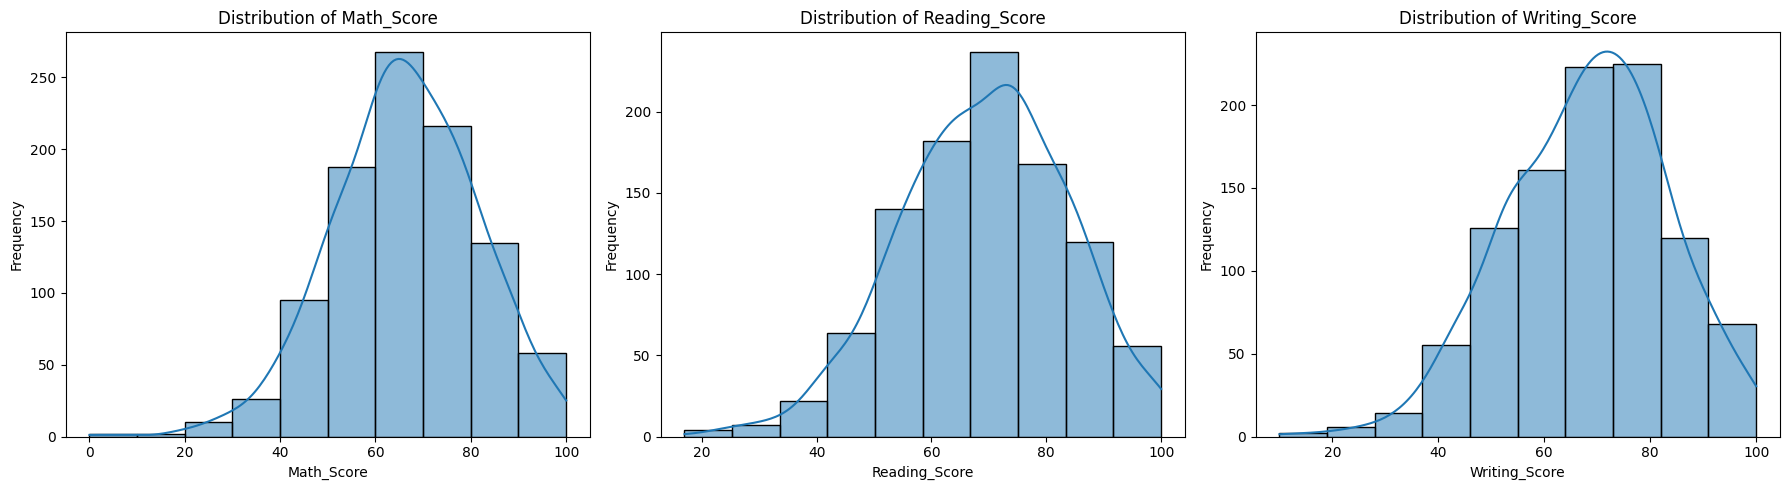

Math Score: The distribution appears to be roughly normal, slightly left-skewed, with a concentration of scores in the 60-80 range.
Reading Score: This distribution is also roughly normal but tends to be slightly left-skewed, with higher scores being more frequent, particularly in the 65-85 range.
Writing Score: Similar to reading, the writing score distribution is slightly left-skewed, indicating a higher frequency of good scores, clustering around 60-80.


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, subject in enumerate(subject_scores):
    sns.histplot(df[subject], bins=10, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {subject.title()}')
    axes[i].set_xlabel(subject.title())
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()



print("Math Score: The distribution appears to be roughly normal, slightly left-skewed, with a concentration of scores in the 60-80 range.")
print("Reading Score: This distribution is also roughly normal but tends to be slightly left-skewed, with higher scores being more frequent, particularly in the 65-85 range.")
print("Writing Score: Similar to reading, the writing score distribution is slightly left-skewed, indicating a higher frequency of good scores, clustering around 60-80.")

### 2. Box Plots by Gender

/tmp/ipykernel_426/2478052905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=subject, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_426/2478052905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=subject, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_426/2478052905.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y=subject, data=df, ax=axes[i], palette='viridis')


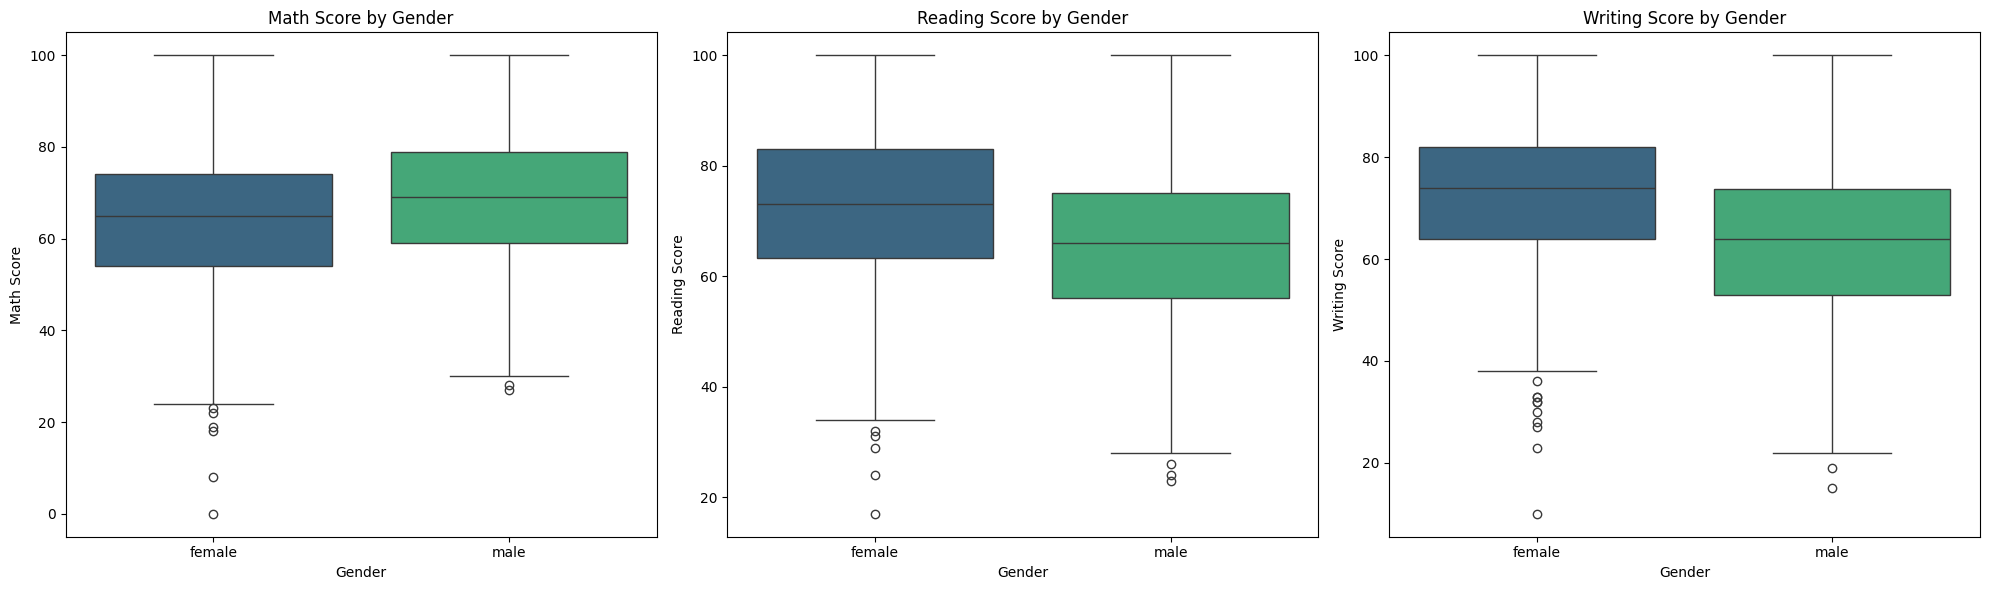


--- Observations from Box Plots ---
Math Score: Males generally show higher median math scores and a wider spread, while females have a tighter distribution but with some lower outliers.
Reading Score: Females show significantly higher median reading scores and a more concentrated distribution than males.
Writing Score: Similar to reading, females have notably higher median writing scores and a slightly wider but generally higher-scoring distribution compared to males. Outliers are present at the lower end for both genders across all subjects.


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, subject in enumerate(subject_scores):
    sns.boxplot(x='gender', y=subject, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{subject.title()} by Gender')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel(subject.title())

plt.tight_layout()
plt.show()


print("Math Score: Males generally show higher median math scores and a wider spread, while females have a tighter distribution but with some lower outliers.")
print("Reading Score: Females show significantly higher median reading scores and a more concentrated distribution than males.")
print("Writing Score: Similar to reading, females have notably higher median writing scores and a slightly wider but generally higher-scoring distribution compared to males. Outliers are present at the lower end for both genders across all subjects.")

### 3. Bar Plot – Average Scores by Lunch Type

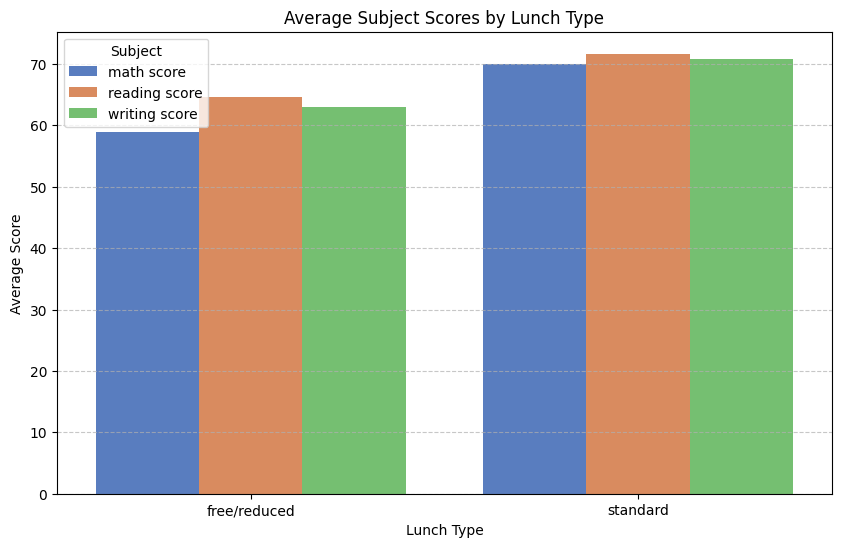

In [27]:
avg_scores_lunch = df.groupby('lunch')[subject_scores].mean().reset_index()
avg_scores_lunch_melted = avg_scores_lunch.melt(id_vars='lunch', var_name='Subject', value_name='Average Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='lunch', y='Average Score', hue='Subject', data=avg_scores_lunch_melted, palette='muted')
plt.title('Average Subject Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Average Score')
plt.legend(title='Subject')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 4. Scatter Plot – Math vs Reading Scores

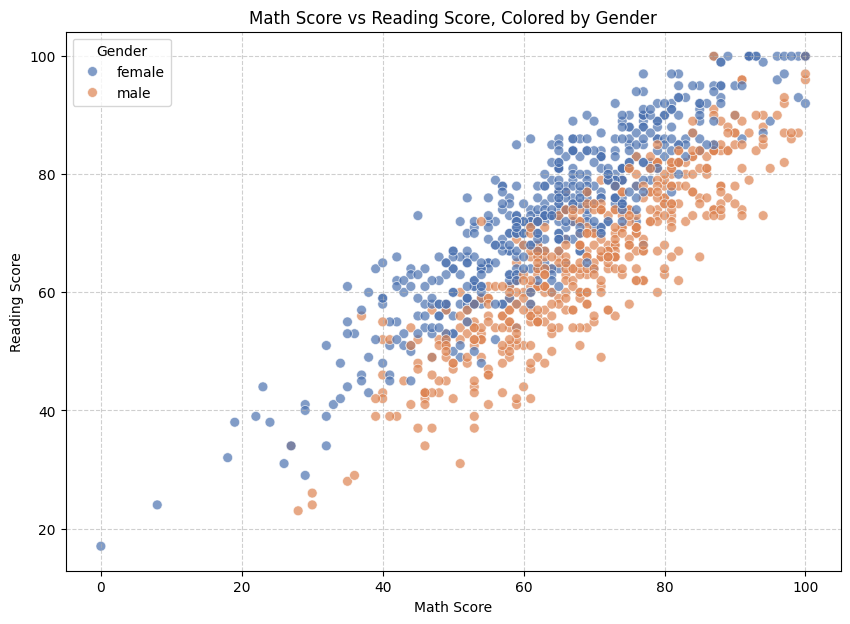

In [47]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='math_score', y='reading_score', hue='gender', data=df, palette='deep', s=50, alpha=0.7)
plt.title('Math Score vs Reading Score, Colored by Gender')
plt.xlabel('Math Score')
plt.ylabel('Reading Score')
plt.legend(title='Gender')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### 5. Line Plot – Parental Education Level Trend

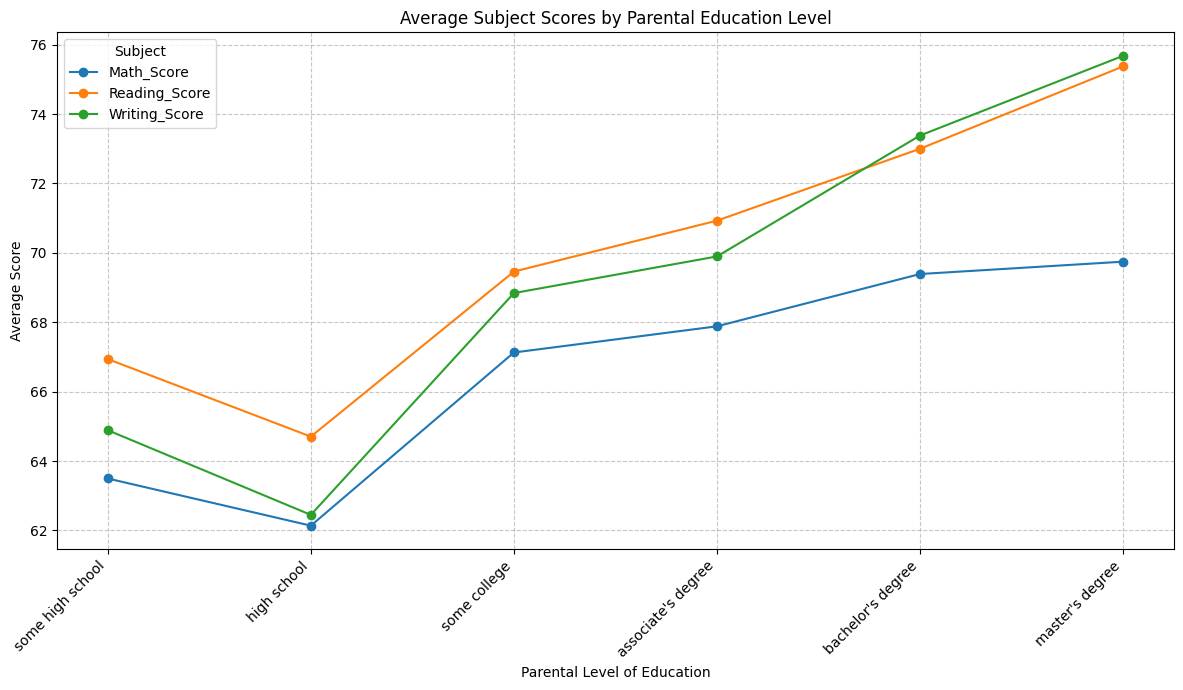

In [54]:
education_order = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

avg_scores_education = df.groupby('parental_level_of_education')[subject_scores].mean().reindex(education_order)

plt.figure(figsize=(12, 7))
for subject in subject_scores:
    plt.plot(avg_scores_education.index, avg_scores_education[subject], marker='o', label=subject.title())

plt.title('Average Subject Scores by Parental Education Level')
plt.xlabel('Parental Level of Education')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subject')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Performance Analysis Report

**Overall Performance Trends:**
The analysis of subject scores reveals that students generally perform better in reading and writing compared to math. Reading scores have the highest mean (69.17), followed closely by writing (68.05), while math trails slightly (66.09). All distributions show a concentration of scores in the 60-80 range, indicating a generally moderate performance across the board with some left-skewness, suggesting a tendency towards higher scores for the majority.

**Influence of Gender, Lunch Type, and Parental Education:**
*   **Gender:** A clear difference is observed, with **males achieving higher average math scores**, while **females significantly outperform males in both reading and writing scores**. This pattern is consistent across the box plots.
*   **Lunch Type:** Students receiving a **'standard' lunch consistently show higher average scores** across all three subjects compared to those with 'free/reduced' lunch. This difference is substantial, highlighting a potential socio-economic impact on academic performance.
*   **Parental Education:** There is a strong positive correlation between parental education level and student performance. As the level of parental education increases from 'some high school' to 'master's degree', the average scores in all subjects generally rise. **Students with parents holding a master's degree achieved the highest average scores**.

**Surprising/Notable Patterns:**
One notable pattern is the clear gender-based discrepancy in subject strengths: while males exhibit a modest advantage in math, females show a more pronounced lead in language-based subjects. The consistent and significant score difference linked to lunch type is also a critical observation.

**Practical Recommendations:**
1.  **Targeted Support:** Schools could implement targeted intervention programs for students on 'free/reduced' lunch to address underlying factors affecting their academic performance, possibly including nutritional support or additional learning resources.
2.  **Gender-Specific Pedagogies:** Teachers might consider incorporating diverse teaching methodologies in math classes to engage female students more effectively, and similarly, in reading and writing for male students, to balance performance across genders and subjects.